Descargando archivo de audio desde GitHub...
¡Descarga exitosa!


/tmp/ipykernel_14284/1714281900.py:40: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ARew = integrate.quad(lambda t: ft(t) * g(t, w).real, x.min(), x.max())[0]
/tmp/ipykernel_14284/1714281900.py:41: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  AImw = integrate.quad(lambda t: ft(t) * g(t, w).imag, x.min(), x.max())[0]
/tmp/ipykernel_14284/1714281900.py:41: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  AImw = integrate.quad(lambda t: ft(t) * g(t, w).imag, x.min(), x.max())[0]
/tmp/ipykernel_14284/1714281900.py:40: 

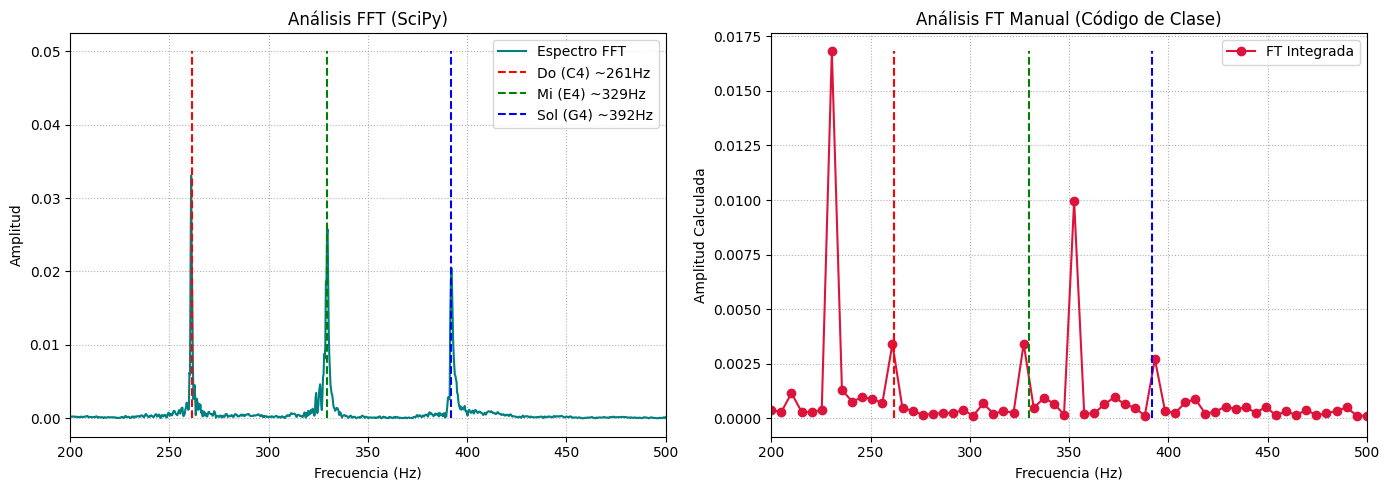

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import requests
from scipy.fft import fft, fftfreq
from scipy import interpolate
import scipy.integrate as integrate

# DESCARGA DEL ARCHIVO DESDE GITHUB
url_github = "https://raw.githubusercontent.com/hugofernandobocanegra2/Fisica_Computacional_1/main/Sesiones/Fourier/Nota_CM_piano.mp3"
archivo_local = "Nota_CM_piano.mp3"

print("Descargando archivo de audio desde GitHub...")
response = requests.get(url_github)
if response.status_code == 200:
    with open(archivo_local, 'wb') as f:
        f.write(response.content)
    print("¡Descarga exitosa!")
else:
    raise FileNotFoundError(f"No se pudo descargar el archivo. Código de estado: {response.status_code}")

 #CARGA DE LA SEÑAL
signal, sr = librosa.load(archivo_local, sr=None)
t_total = np.linspace(0, len(signal)/sr, len(signal))

# FUNCIONES DE LAS NOTAS DE CLASE
def g(t, w):
    """Base continua de Fourier según las notas de clase"""
    return 1./(2*np.pi) * np.exp(-1j * 2 * np.pi * w * t)

def FT(x, y, w_range):
    """Rutina de clase modificada para mapear el espectro por integración"""
    # Interpolación cúbica de los datos discretos
    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    ft = lambda t: f_interp(t)

    amplitudes = []
    for w in w_range:
        # Integración numérica de la parte Real e Imaginaria
        ARew = integrate.quad(lambda t: ft(t) * g(t, w).real, x.min(), x.max())[0]
        AImw = integrate.quad(lambda t: ft(t) * g(t, w).imag, x.min(), x.max())[0]
        # Cálculo de la Magnitud/Amplitud
        AMP = np.sqrt(ARew**2 + AImw**2)
        amplitudes.append(AMP)
    return np.array(amplitudes)

#  EJECUCIÓN: MÉTODO 1 - FFT (SciPy/NumPy)
N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 1 / sr)

#  EJECUCIÓN: MÉTODO 2 - FT MANUAL (Rutina de Clase)
paso = 1
ventana = int(0.5 * sr)  # Analizamos los primeros 0.5 segundos
t_sub = t_total[:ventana:paso]
signal_sub = signal[:ventana:paso]

# Rango de frecuencias objetivo (enfocado en el Do Mayor: 200 Hz a 500 Hz)
frecuencias_busqueda = np.linspace(200, 500, 60)
amp_manual = FT(t_sub, signal_sub, frecuencias_busqueda)

plt.figure(figsize=(14, 5))

# Subplot 1: FFT estándar de SciPy
plt.subplot(1, 2, 1)
idx_positivo = np.where(xf >= 0)
plt.plot(xf[idx_positivo], 2.0/N * np.abs(yf[idx_positivo]), color='teal', label='Espectro FFT')
# Líneas de referencia para las notas reales del acorde
plt.vlines(261.63, 0, 0.05, colors='r', linestyles='--', label='Do (C4) ~261Hz')
plt.vlines(329.63, 0, 0.05, colors='g', linestyles='--', label='Mi (E4) ~329Hz')
plt.vlines(392.00, 0, 0.05, colors='b', linestyles='--', label='Sol (G4) ~392Hz')
plt.title('Análisis FFT (SciPy)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.xlim(200, 500)  # <-- Mejora aplicada aquí
plt.grid(True, linestyle=':')
plt.legend()

# Subplot 2: FT manual de clase por integración
plt.subplot(1, 2, 2)
plt.plot(frecuencias_busqueda, amp_manual, 'o-', color='crimson', label='FT Integrada')
plt.vlines(261.63, 0, max(amp_manual), colors='r', linestyles='--')
plt.vlines(329.63, 0, max(amp_manual), colors='g', linestyles='--')
plt.vlines(392.00, 0, max(amp_manual), colors='b', linestyles='--')
plt.title('Análisis FT Manual (Código de Clase)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud Calculada')
plt.xlim(200, 500)
plt.grid(True, linestyle=':')
plt.legend()

plt.tight_layout()
plt.show()

### Análisis de los resultados




En lel código de clase las líneas verde (Mi ~329Hz) y azul (Sol ~392Hz)y roja (Do ≈ 261 Hz), **tienes puntos rojos que coinciden** con esas frecuencias. Al darle a la función todos los datos de la señal, se logra  la resolución suficiente para "ver" esas oscilaciones más rápidas.

También se nota que aparecen unos picos gigantes donde no deberían estar (alrededor de 230 Hz y 350 Hz). Se cree que esto puede suceder por la integración numerica de funciones que oscilan muchas veces lo cual intriduce un error acumulativo que se manifiesta en la creación de picos falsos.
